In [43]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from termcolor import colored
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn import set_config
set_config(print_changed_only = False)

#to see full text:

print(colored("\nNECESSARY LIBRARIES WERE SUCCESFULLY IMPORTED...", color = "green", attrs = ["bold", "dark"]))



NECESSARY LIBRARIES WERE SUCCESFULLY IMPORTED...


In [63]:
train = pd.read_csv('./data/train_prep.csv').dropna()
test = pd.read_csv('./data/test_prep.csv').dropna()
y_train = train['target']
y_test = test['target']

In [64]:
train.isna().sum()

target    0
text      0
ch_no     0
wd_no     0
sn_no     0
dtype: int64

In [65]:
data = pd.concat([train, test], axis=0, ignore_index=True)

data

,target,text,ch_no,wd_no,sn_no
0,0,tired special,36,7,1
1,0,yeah apologetic. fallen actin like spoilt chil...,189,48,6
2,0,need anything know outsider,54,14,2
3,0,want send something sell fast. &lt;#&gt; easy ...,76,23,2
4,0,think make oreo truffles.,47,12,2
...,...,...,...,...,...
5148,1,want nokia 3510i colour phone deliveredtomorro...,158,30,2
5149,0,hey. happened? switch cell whole day. isnt goo...,112,30,5
5150,0,spoon okay?,23,6,1
5151,0,watching telugu movie..wat,33,8,1


In [66]:

from sklearn.model_selection import train_test_split


x = data['text']
y = data["target"]

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.20, shuffle = True, random_state = 11)

print(colored("\nDATASET WAS SUCCESFULLY DIVIDED ...", color = "green", attrs = ["bold", "dark"]))




DATASET WAS SUCCESFULLY DIVIDED ...


In [5]:
train

,target,text,ch_no,wd_no,sn_no
0,0,tired special,36,7,1
1,0,yeah apologetic. fallen actin like spoilt chil...,189,48,6
2,0,need anything know outsider,54,14,2
3,0,want send something sell fast. &lt;#&gt; easy ...,76,23,2
4,0,think make oreo truffles.,47,12,2
...,...,...,...,...,...
3613,0,k.k.how business now?,29,6,1
3614,0,taking forever prescription. pharmacy like min...,92,20,3
3615,1,receiving week's triple echo ringtone shortly....,73,15,2
3616,0,come home last time wont anything. trust,63,16,2



**Preparing the input features for training**

We converting the text words into arrays form.

Maximum 500 features/words selected for training. These 500 words will be selected on the importance that will distinguish between the positive tweets and negative tweets.



In [20]:
X = train['text'].astype(str)
X_test = test['text'].astype(str)
y = train['target']
y_test = test['target']

In [ ]:
num_words = 20000  # good balance for your dataset

tok = Tokenizer(num_words=num_words, oov_token="<OOV>")
tok.fit_on_texts(X)
num_words = 20000  # good balance for your dataset

tok = Tokenizer(num_words=num_words, oov_token="<OOV>")
tok.fit_on_texts(X)

sequences = tok.texts_to_sequences(X)
test_sequences = tok.texts_to_sequences(X_test)

max_len = 80  # best balance for your distribution

X_train_pad = sequence.pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = sequence.pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

NameError: name 'sequence' is not defined

In [25]:
def build_model():

    inputs = Input(shape=(max_len,))

    # Embedding layer
    layer = Embedding(
        input_dim=num_words,
        output_dim=100,     # embedding size (NOT max_len)
        input_length=max_len,
        mask_zero=True      # IMPORTANT
    )(inputs)

    # LSTM layer
    layer = LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.2
    )(layer)

    # Fully connected layer
    layer = Dense(128, activation='relu')(layer)
    layer = Dropout(0.5)(layer)

    # Output layer (binary classification)
    outputs = Dense(1, activation='sigmoid')(layer)

    model = Model(inputs=inputs, outputs=outputs)

    return model

In [26]:
model = build_model()

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/home/ismail/miniconda/envs/tf-dl/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
    3/18000 ━━━━━━━━━━━━━━━━━━━━ 14:49 49ms/step - accuracy: 0.5312 - loss: 0.6929

E0000 00:00:1776519978.466617 3713721 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


18000/18000 ━━━━━━━━━━━━━━━━━━━━ 856s 47ms/step - accuracy: 0.8076 - loss: 0.4203 - val_accuracy: 0.8227 - val_loss: 0.3878
Epoch 2/10
18000/18000 ━━━━━━━━━━━━━━━━━━━━ 977s 54ms/step - accuracy: 0.8306 - loss: 0.3787 - val_accuracy: 0.8279 - val_loss: 0.3771
Epoch 3/10
18000/18000 ━━━━━━━━━━━━━━━━━━━━ 1050s 58ms/step - accuracy: 0.8411 - loss: 0.3587 - val_accuracy: 0.8329 - val_loss: 0.3778
Epoch 4/10
18000/18000 ━━━━━━━━━━━━━━━━━━━━ 1074s 60ms/step - accuracy: 0.8489 - loss: 0.3440 - val_accuracy: 0.8329 - val_loss: 0.3731
Epoch 5/10
18000/18000 ━━━━━━━━━━━━━━━━━━━━ 1050s 58ms/step - accuracy: 0.8553 - loss: 0.3320 - val_accuracy: 0.8323 - val_loss: 0.3842
Epoch 6/10
18000/18000 ━━━━━━━━━━━━━━━━━━━━ 971s 54ms/step - accuracy: 0.8602 - loss: 0.3219 - val_accuracy: 0.8312 - val_loss: 0.3937


In [29]:
accr2 = model.evaluate(X_test_pad,y_test) #we are starting to test the model here

print('Test set\n  Accuracy: {:0.2f}'.format(accr2[1])) #the accuracy of the model on test data is given below

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 109s 11ms/step - accuracy: 0.8336 - loss: 0.3743
Test set
  Accuracy: 0.83


In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     ngram_range=(1, 2),
#     max_features=50000
# )
# tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5))
tfidf = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    max_features=50000,
    sublinear_tf=True
)
X_train = tfidf.fit_transform(train['text'])
X_test  = tfidf.transform(test['text'])

print('Vectorizer fitted.')
print('No. of feature_words:', len(tfidf.get_feature_names_out()))

Vectorizer fitted.
No. of feature_words: 5531


In [117]:
from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     ngram_range=(1, 2),
#     max_features=50000
# )
# tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5))
char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=30000
)
X_train_char = char_tfidf.fit_transform(train['text'])
X_test_char  = char_tfidf.transform(test['text'])

print('Vectorizer fitted.')
print('No. of feature_words:', len(char_tfidf.get_feature_names_out()))

Vectorizer fitted.
No. of feature_words: 30000


In [118]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    # 'text_len',
    # 'word_count',
    # 'caps_ratio',
    # 'caps_count',
    # 'punctuation_count'
    'ch_no','wd_no','sn_no'
]
print(train[num_cols].isna().sum())
X_num_train = train[num_cols].values
X_num_test  = test[num_cols].values


scaler = StandardScaler()

X_num_train = scaler.fit_transform(X_num_train)
X_num_test  = scaler.transform(X_num_test)


ch_no    0
wd_no    0
sn_no    0
dtype: int64


In [119]:
from scipy.sparse import hstack

X_train_hybrid = hstack([X_train, X_train_char, X_num_train])

X_test_hybrid  = hstack([X_test, X_test_char, X_num_test])

In [10]:
from scipy.sparse import save_npz

save_npz("X_train_hybrid.npz", X_train_hybrid)
save_npz("X_test_hybrid.npz", X_test_hybrid)

In [11]:
from scipy.sparse import load_npz

X_train_hybrid = load_npz("X_train_hybrid.npz")
X_test_hybrid  = load_npz("X_test_hybrid.npz")

In [22]:
import numpy as np

def load_glove_embeddings(path):
    embeddings_index = {}
    
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    
    return embeddings_index

glove_embeddings = load_glove_embeddings('glove.6B.50d.txt')

def sentence_vector(text, embeddings, dim=50):
    words = text.split()
    
    vectors = [embeddings[w] for w in words if w in embeddings]
    
    if len(vectors) == 0:
        return np.zeros(dim)
    
    return np.mean(vectors, axis=0)

X_glove_train = np.array([
    sentence_vector(text, glove_embeddings, dim=50)
    for text in train['text']
])

X_glove_test = np.array([
    sentence_vector(text, glove_embeddings, dim=50)
    for text in test['text']
])

In [23]:
from sklearn.preprocessing import normalize

X_glove_train = normalize(X_glove_train)
X_glove_test  = normalize(X_glove_test)

In [26]:
from scipy.sparse import hstack

X_train_hybrid = hstack([X_train_hybrid, X_glove_train * 0.6])

X_test_hybrid  = hstack([X_test_hybrid, X_glove_test * 0.6])

In [1]:
train

NameError: name 'train' is not defined

In [112]:


def model_Evaluate(model, test_data):
    
    # Predict values for Test dataset
    y_pred = model.predict(test_data)

    # Print the evaluation metrics for the dataset.
    print(classification_report(y_test, y_pred))
    
    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)

    categories  = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]

    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)

    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)


In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier


**ComplementNB/MultinomialNB??????**

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1352
           1       0.97      0.80      0.87       196

    accuracy                           0.97      1548
   macro avg       0.97      0.90      0.93      1548
weighted avg       0.97      0.97      0.97      1548



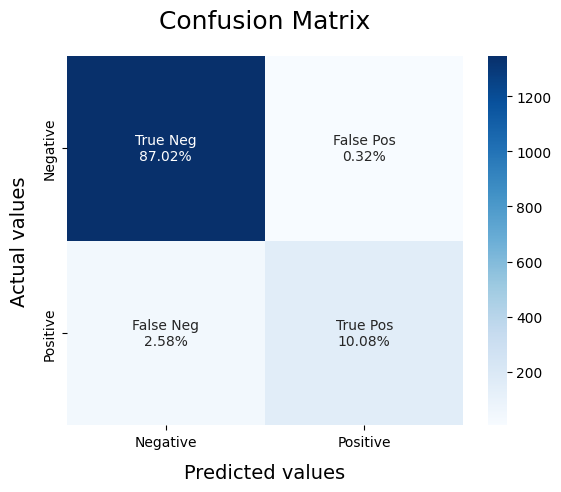

In [28]:


from sklearn.naive_bayes import BernoulliNB


BNBmodel = BernoulliNB(alpha = 2)
BNBmodel.fit(X_train_hybrid, y_train)
model_Evaluate(BNBmodel,X_test_hybrid)



              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1352
           1       0.96      0.91      0.94       196

    accuracy                           0.98      1548
   macro avg       0.97      0.95      0.96      1548
weighted avg       0.98      0.98      0.98      1548



/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


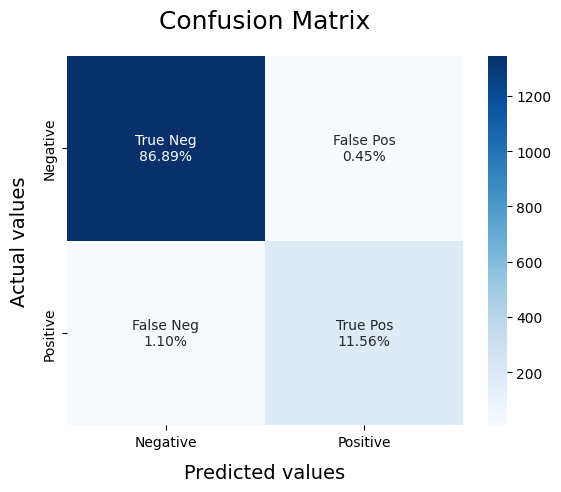

In [29]:
SVCmodel = LinearSVC()
SVCmodel.fit(X_train_hybrid, y_train)
model_Evaluate(SVCmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1352
           1       0.97      0.87      0.92       196

    accuracy                           0.98      1548
   macro avg       0.97      0.93      0.95      1548
weighted avg       0.98      0.98      0.98      1548



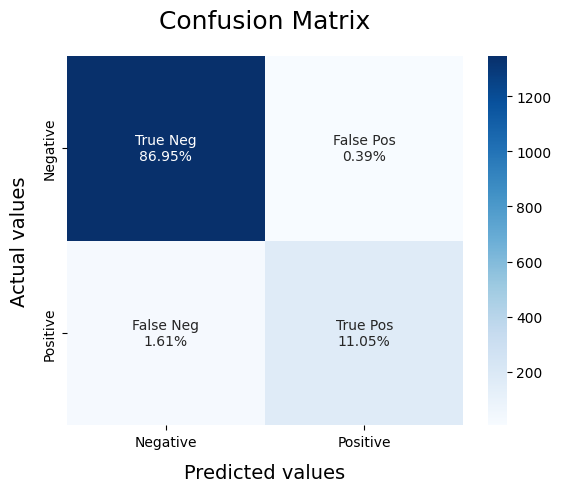

In [30]:
LRmodel = LogisticRegression(C = 2, max_iter = 1000)
LRmodel.fit(X_train_hybrid, y_train)
model_Evaluate(LRmodel, X_test_hybrid)




[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Number of positive: 457, number of negative: 3148
[LightGBM] [Info] Total Bins 82993
[LightGBM] [Info] Number of data points in the train set: 3605, number of used features: 4472
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.126768 -> initscore=-1.929839
[LightGBM] [Info] Start t

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


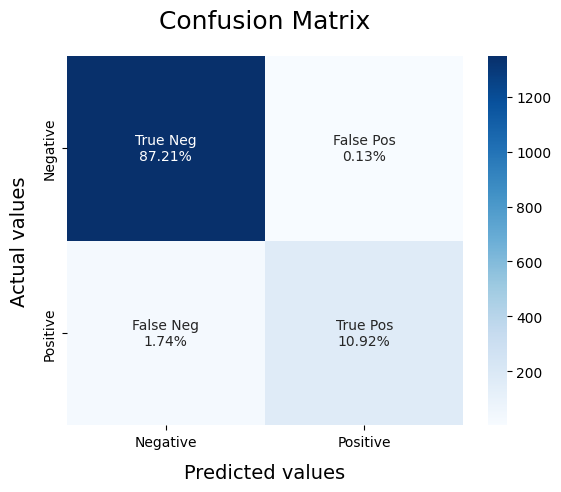

In [20]:
import lightgbm as lgb

# LGBmodel = lgb.LGBMClassifier(
#     n_estimators=1000,
#     learning_rate=0.05
# )

# from sklearn.decomposition import TruncatedSVD

# svd = TruncatedSVD(n_components=300)

# X_train_reduced = svd.fit_transform(X_train_hybrid)
# X_test_reduced = svd.transform(X_test_hybrid)
LGBmodel = lgb.LGBMClassifier(
    n_estimators=200,       # ↓ from 1000
    learning_rate=0.1,      # ↑ to compensate
    num_leaves=31,
    n_jobs=-1,
    max_depth=6,
    feature_fraction=0.1,
    bagging_fraction=0.8,
    bagging_freq=1,
    max_bin=63,
    force_col_wise=True,
)
LGBmodel.fit(X_train_hybrid, y_train)
model_Evaluate(LGBmodel, X_test_hybrid)


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1352
           1       0.95      0.90      0.92       196

    accuracy                           0.98      1548
   macro avg       0.97      0.95      0.96      1548
weighted avg       0.98      0.98      0.98      1548



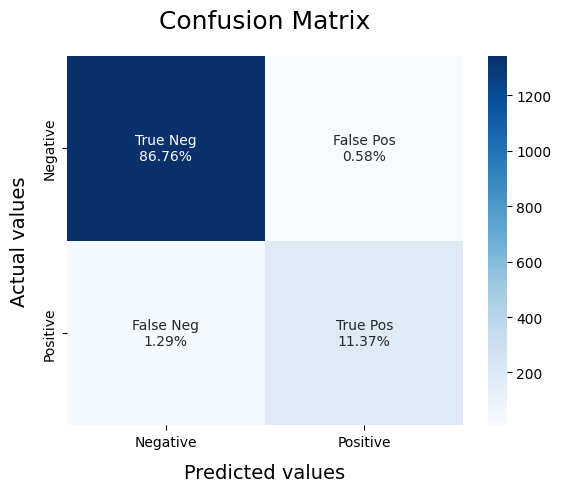

In [31]:
from sklearn.linear_model import SGDClassifier

SGDmodel = SGDClassifier(loss='log_loss', max_iter=1000, n_jobs=-1)
SGDmodel.fit(X_train_hybrid, y_train)
model_Evaluate(SGDmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1352
           1       0.89      0.79      0.83       196

    accuracy                           0.96      1548
   macro avg       0.93      0.89      0.91      1548
weighted avg       0.96      0.96      0.96      1548



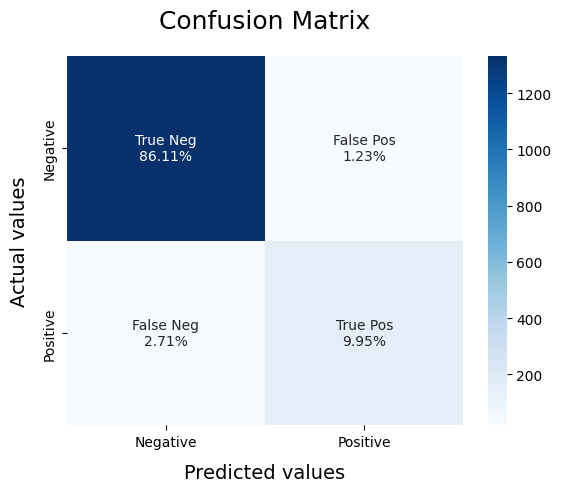

In [ ]:
kncmodel = KNeighborsClassifier()
kncmodel.fit(X_train_hybrid, y_train)
model_Evaluate(kncmodel, X_test_hybrid)

In [125]:
MNBmodel = MultinomialNB()
MNBmodel.fit(X_train_hybrid, y_train)
model_Evaluate(MNBmodel, X_test_hybrid)

ValueError: Negative values in data passed to MultinomialNB (input X).

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1352
           1       0.95      0.74      0.84       196

    accuracy                           0.96      1548
   macro avg       0.96      0.87      0.91      1548
weighted avg       0.96      0.96      0.96      1548



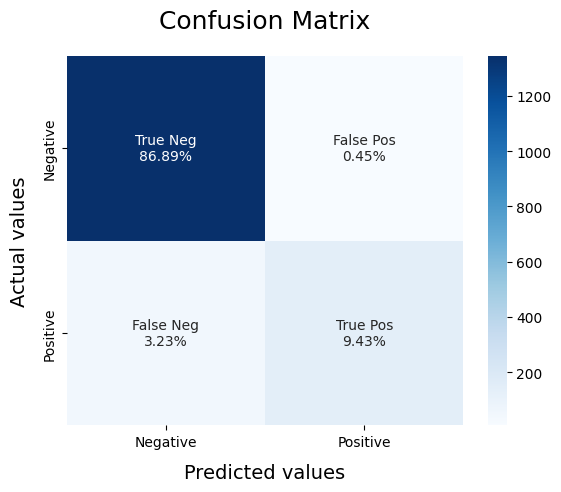

In [126]:
DTCmodel = DecisionTreeClassifier(max_depth = 5)
DTCmodel.fit(X_train_hybrid, y_train)
model_Evaluate(DTCmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1352
           1       0.97      0.87      0.92       196

    accuracy                           0.98      1548
   macro avg       0.98      0.93      0.95      1548
weighted avg       0.98      0.98      0.98      1548



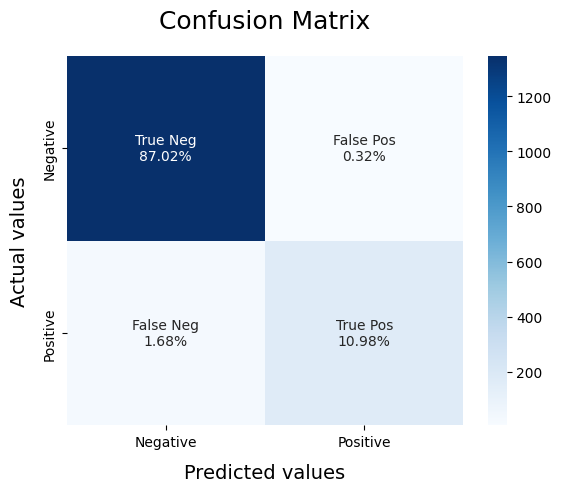

In [127]:
RFmodel = RandomForestClassifier(n_estimators = 50, random_state = 2 )
RFmodel.fit(X_train_hybrid, y_train)
model_Evaluate(RFmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1352
           1       0.98      0.82      0.89       196

    accuracy                           0.97      1548
   macro avg       0.97      0.91      0.94      1548
weighted avg       0.97      0.97      0.97      1548



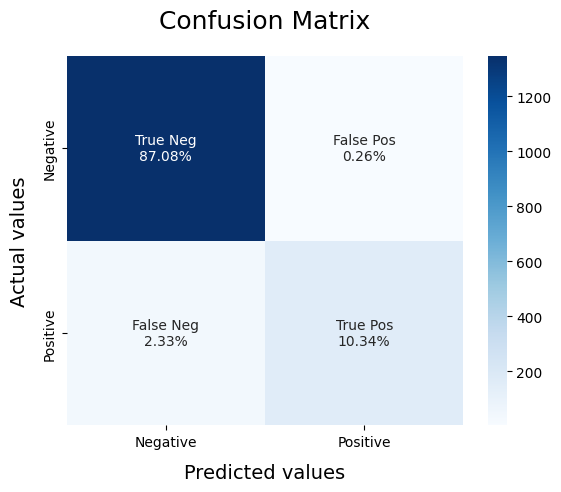

In [128]:

ADAmodel = AdaBoostClassifier(n_estimators = 50, random_state = 2)
ADAmodel.fit(X_train_hybrid, y_train)
model_Evaluate(ADAmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1352
           1       0.96      0.90      0.93       196

    accuracy                           0.98      1548
   macro avg       0.97      0.95      0.96      1548
weighted avg       0.98      0.98      0.98      1548



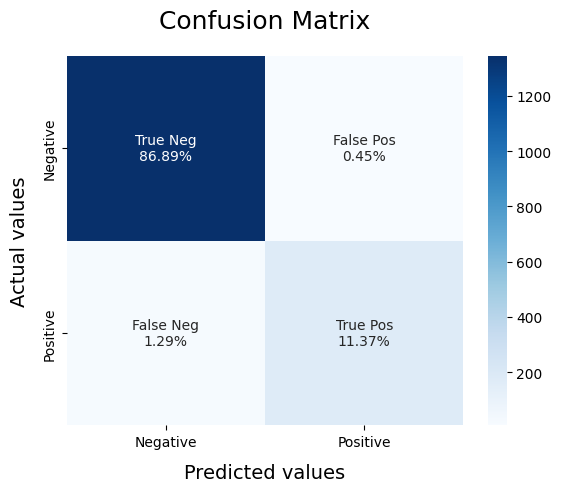

In [124]:
BGmodel = BaggingClassifier(n_estimators = 50, random_state = 2)
BGmodel.fit(X_train_hybrid, y_train)
model_Evaluate(BGmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1352
           1       0.97      0.89      0.93       196

    accuracy                           0.98      1548
   macro avg       0.98      0.94      0.96      1548
weighted avg       0.98      0.98      0.98      1548



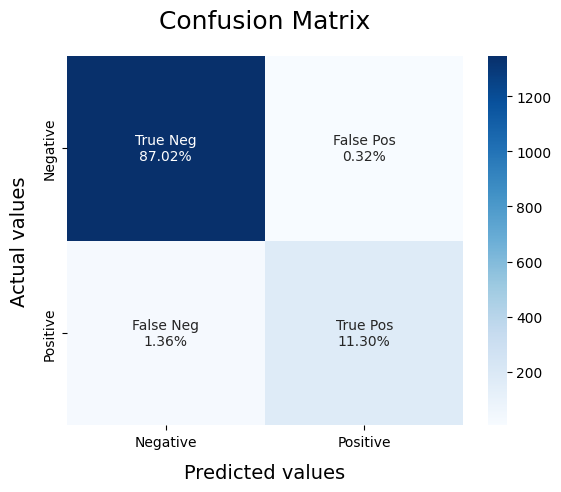

In [123]:
ETCmodel = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
ETCmodel.fit(X_train_hybrid, y_train)
model_Evaluate(ETCmodel, X_test_hybrid)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1352
           1       0.99      0.80      0.89       196

    accuracy                           0.97      1548
   macro avg       0.98      0.90      0.94      1548
weighted avg       0.97      0.97      0.97      1548



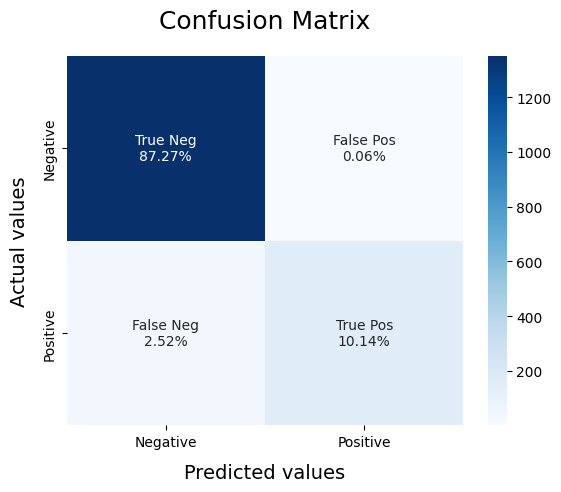

In [122]:
GBDTmodel = GradientBoostingClassifier(n_estimators = 50, random_state = 2)    
GBDTmodel.fit(X_train_hybrid, y_train)
model_Evaluate(GBDTmodel, X_test_hybrid)

In [ ]:
XGBmodel  = XGBClassifier(n_estimators = 50, random_state = 2)
XGBmodel.fit(X_train_hybrid, y_train)
model_Evaluate(XGBmodel, X_test_hybrid)

In [1]:
del X_train
del X_test

NameError: name 'X_train' is not defined